In [44]:
import os
from brainnetwork import load_data, preprocess_data, preprocess_spike_data
from brainnetwork import classify_by_timepoints, FI_by_timepoints_v2, FI_by_neuron_count
from brainnetwork import construct_correlation_network, compute_network_metrics_by_class
from brainnetwork.visualization import *

In [45]:
base_dir = "/beegfs_hdd/data/nfs_share/users/guiyun/nishome/Micedata/"
data_paths = ["M21_1107", "M71_1024", "M73_1128", "M77_1028", "M77_1031", "M77_1107", "M78_1017", "M79_1128", "M91_1017"]
data_path = base_dir + data_paths[7] # 'M77_1031'
print(f"Processing data from: {data_path}")

Processing data from: /beegfs_hdd/data/nfs_share/users/guiyun/nishome/Micedata/M79_1128


In [46]:
neuron_data, neuron_pos, start_edges, stimulus_data = load_data(data_path)
segments_spi, labels_spi, neuron_pos_spi = preprocess_spike_data(
        neuron_data,
        neuron_pos,
        start_edges,
        stimulus_data,
    )
neuron_data_flo, neuron_pos_flo, start_edges_flo, stimulus_data_flo = load_data(data_path, data_type='fluorescence')
segments_flo, labels_flo, neuron_pos_flo = preprocess_data(
    neuron_data_flo,
    neuron_pos_flo,
    start_edges_flo,
    stimulus_data_flo,
)

原始神经数据形状: (8402, 27033)
使用快速RR筛选算法 (按类分别筛选取并集)...
  - 类别 1 贡献了 262 个 RR 神经元
  - 类别 2 贡献了 253 个 RR 神经元
  - 类别 3 贡献了 188 个 RR 神经元
三类并集后共筛选出 365 个唯一 RR 神经元
原始神经数据形状: (8402, 27061)
使用快速RR筛选算法 (按类分别筛选取并集)...
  - 类别 1 贡献了 577 个 RR 神经元
  - 类别 2 贡献了 520 个 RR 神经元
  - 类别 3 贡献了 414 个 RR 神经元
三类并集后共筛选出 748 个唯一 RR 神经元


In [47]:
# %% 可视化相关函数定义
from tifffile import imread 
import numpy as np
import scipy.stats as stats

def rr_distribution_plot_pretty(neuron_pos, neuron_pos_rr, data_path,
                                x_total_mm=7.0,
                                scalebar_mm=1.0,
                                gamma=1.25,
                                bg_p_low=2,
                                bg_p_high=98):
    """
    优化版 RR neuron distribution plot
    - All neurons: 用密度图(hist2d)避免点重叠
    - RR neurons: 散点+白色描边更清楚
    - 去坐标轴：保留比例尺（X轴总长=7mm）
    - 背景：更柔和对比度 + gamma 压亮度
    """
    from matplotlib.colors import LogNorm
    from matplotlib.patches import Rectangle
    fig, ax = plt.subplots(figsize=(8.5, 7), dpi=200)

    # --- 背景图像 ---
    brain_img = imread(f"{data_path}/whole_brain_3d.tif")
    mid_slice = brain_img[brain_img.shape[0] // 4, :, :].astype(np.float32)

    # normalize to [0,1]
    mid_slice = mid_slice - np.nanmin(mid_slice)
    mid_slice = mid_slice / (np.nanmax(mid_slice) + 1e-8)

    # 温和对比度拉伸（避免过强）
    vmin = np.percentile(mid_slice, bg_p_low)
    vmax = np.percentile(mid_slice, bg_p_high)
    bg = np.clip((mid_slice - vmin) / (vmax - vmin + 1e-8), 0, 1)

    # gamma > 1 会压暗中高亮区域（整体不那么亮、对比不刺）
    if gamma is not None:
        bg = bg ** gamma

    ax.imshow(bg, cmap="gray", interpolation="nearest")

    # =======================
    # All neurons（散点，极轻）
    # =======================
    ax.scatter(
        neuron_pos[1, :],
        neuron_pos[0, :],
        s=10,                    # 非常小
        c="#6B7B61",               # 冷灰
        alpha=0.3,             # 极低透明度
        marker="o",
        linewidths=0,
        rasterized=True,        # 导出 PDF 非常重要
        zorder=2
    )


    # --- RR neurons：散点更醒目 + 描边 ---
    x_rr = neuron_pos_rr[1, :]
    y_rr = neuron_pos_rr[0, :]

    ax.scatter(
        x_rr, y_rr,
        s=40,
        c="#1ada4a",
        alpha=0.9,
        linewidths=0.6,
        edgecolors="#000000",   # 白描边让红点从背景里“跳出来”
        zorder=5
    )

    # --- 去掉坐标轴/网格/边框 ---
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)

    # --- 比例尺（X轴总长=7mm） ---
    # 像素->mm：整张图宽 bg.shape[1] 像素对应 x_total_mm mm
    px_per_mm = bg.shape[1] / x_total_mm
    bar_px = scalebar_mm * px_per_mm

    # 放在右下角，留一点边距
    pad = 0.04
    x0 = bg.shape[1] * (1 - pad) - bar_px
    y0 = bg.shape[0] * (1 - pad)

    bar_h = max(6, int(bg.shape[0] * 0.004))  # 比例尺厚度随图大小自适应
    ax.add_patch(Rectangle((x0, y0 - bar_h), bar_px, bar_h,
                           facecolor="white", edgecolor="none", zorder=10))
    ax.text(x0 + bar_px / 2, y0 - bar_h - 15,
            f"{scalebar_mm:g} mm",
            color="white", ha="center", va="bottom",
            fontsize=11, weight="bold", zorder=10)

    # --- 标题（可选：如果你也想去掉标题，把下一行注释掉） ---
    # ax.set_title("RR Neuron Distribution", fontsize=16, pad=10)

    plt.tight_layout()
    plt.show()

def plot_rr_population_average(segments, labels, t_stimulus = 10, l_stimulus = 20, l_last=20):
    """Plot average responses of all RR neurons to three stimulus types"""
    # Class name mapping
    CLASS_NAMES = {
        3: "Random",
        1: "Convergent",
        2: "Divergent"
    }

    # Unified color scheme
    CLASS_COLORS = {
        1: "#3D5A80",      # Random - deep blue
        2: "#E07A5F",      # Convergent - coral orange
        3: "#81B29A"       # Divergent - sage green
    }

    time_axis = np.arange(segments.shape[2])
    stim_start = t_stimulus
    stim_duration = l_stimulus
    stim_end = stim_start + stim_duration + l_last

    # Create figure
    fig, ax = plt.subplots(figsize=(10, 6))

    # Add elegant stimulus window shading
    ax.axvspan(stim_start, stim_end, color='#FFD166', alpha=0.15, zorder=0, label='Stimulus')
    ax.axhline(y=0, color='#888888', linestyle='-', linewidth=0.5, alpha=0.4, zorder=0)

    # Plot each stimulus type
    for cls in [1, 2, 3]:  # Only plot the three main classes
        cls_mask = labels == cls
        if not np.any(cls_mask):
            continue

        # Get all trials for this class, average across neurons AND trials
        cls_segments = segments[cls_mask]  # (n_trials, n_neurons, n_timepoints)

        # Average across both trials and neurons to get population mean
        population_mean = np.mean(cls_segments, axis=(0, 1))  # (n_timepoints,)

        # Calculate SEM across trials (keeping neurons separate first)
        trial_means = np.mean(cls_segments, axis=1)  # (n_trials, n_timepoints)
        population_sem = stats.sem(trial_means, axis=0, nan_policy='omit')

        color = CLASS_COLORS[cls]
        class_name = CLASS_NAMES[cls]

        # Plot with error band
        ax.fill_between(time_axis,
                       population_mean - population_sem,
                       population_mean + population_sem,
                       color=color, alpha=0.2, zorder=1)
        ax.plot(time_axis, population_mean, color=color, linewidth=2.5,
               label=class_name, zorder=2)

    # Styling
    ax.set_xlabel('Time (frames)', fontsize=13, fontweight='medium')
    ax.set_ylabel('Mean dF/F', fontsize=13, fontweight='medium')
    ax.set_title('Population Average Response of RR Neurons',
                fontsize=15, fontweight='bold', pad=15)
    ax.tick_params(axis='both', which='major', labelsize=11)
    ax.legend(frameon=True, fontsize=11, loc='upper right',
             framealpha=0.95, edgecolor='#cccccc')

    fig.tight_layout()
    plt.show()

def plot_rr_population_average_pretty(
    segments, labels,
    t_stimulus=10, l_stimulus=20, 
    figsize=(6.4, 4.2),   # 整体缩小
    line_width=3.6,       # 曲线加粗
    sem_alpha=0.18        # 阴影更柔
):
    """Plot average responses of all RR neurons to three stimulus types (beautified)"""

    # 类名（保持你的逻辑）
    CLASS_NAMES = {1: "Convergent", 2: "Divergent", 3: "Random"}

    # 更舒服、对比清晰（接近 Okabe-Ito / colorblind-friendly）
    CLASS_COLORS = {
        1: "#1F77B4",  # 蓝
        2: "#D55E00",  # 橙红（更高级的橙）
        3: "#009E73",  # 绿
    }

    time_axis = np.arange(segments.shape[2])
    stim_start = t_stimulus
    stim_end = stim_start + l_stimulus

    fig, ax = plt.subplots(figsize=figsize, dpi=200)

    # ========= 只保留左/下坐标轴 =========
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(axis="both", which="both", top=False, right=False)
    ax.spines["left"].set_linewidth(1.2)
    ax.spines["bottom"].set_linewidth(1.2)

    # 先算出全局 y 范围（为了把刺激条放在曲线下方且不挡曲线）
    # （先不画，先粗算一个 y_min/y_max）
    # 给一个保守的范围：后面再用实际数据更新也行
    y_min_guess = np.nanmin(segments)
    y_max_guess = np.nanmax(segments)

    # ========= 画曲线 =========
    for cls in [1, 2, 3]:
        cls_mask = labels == cls
        if not np.any(cls_mask):
            continue

        cls_segments = segments[cls_mask]  # (n_trials, n_neurons, n_timepoints)

        population_mean = np.nanmean(cls_segments, axis=(0, 1))
        trial_means = np.nanmean(cls_segments, axis=1)  # (n_trials, n_timepoints)
        population_sem = stats.sem(trial_means, axis=0, nan_policy="omit")

        color = CLASS_COLORS[cls]
        name = CLASS_NAMES[cls]

        ax.fill_between(
            time_axis,
            population_mean - population_sem,
            population_mean + population_sem,
            color=color, alpha=sem_alpha, linewidth=0, zorder=1
        )
        ax.plot(
            time_axis, population_mean,
            color=color, linewidth=line_width, solid_capstyle="round",
            label=name, zorder=3
        )

    # 重新用当前轴内容拿到更准确的 y 范围
    y_min, y_max = ax.get_ylim()
    yr = y_max - y_min

    # ========= 刺激条：曲线下方小灰色横向柱子 =========
    # 放在底部上方一点点，留出空间
    bar_h = 0.035 * yr
    bar_y = y_min + 0.06 * yr  # 距离底部一点点
    ax.broken_barh(
        [(stim_start, l_stimulus)],
        (bar_y, bar_h),
        facecolors="#9E9E9E",
        edgecolors="none",
        alpha=0.9,
        zorder=0
    )
    ax.text(
        stim_start + l_stimulus / 2,
        bar_y + bar_h + 0.015 * yr,
        "Stimulus",
        ha="center", va="bottom",
        fontsize=10, color="#666666"
    )

    # ========= 标签与标题 =========
    ax.set_xlabel("Time (frames)", fontsize=12)
    ax.set_ylabel("Mean dF/F", fontsize=12)
    # ax.set_title("Population Average Response of RR Neurons",
    #             fontsize=13.5, weight="bold", pad=10)

    # 更干净的 legend
    leg = ax.legend(
        frameon=False, fontsize=10.5, loc="upper right",
        handlelength=2.4
    )

    ax.margins(x=0.02)
    fig.tight_layout()
    plt.show()

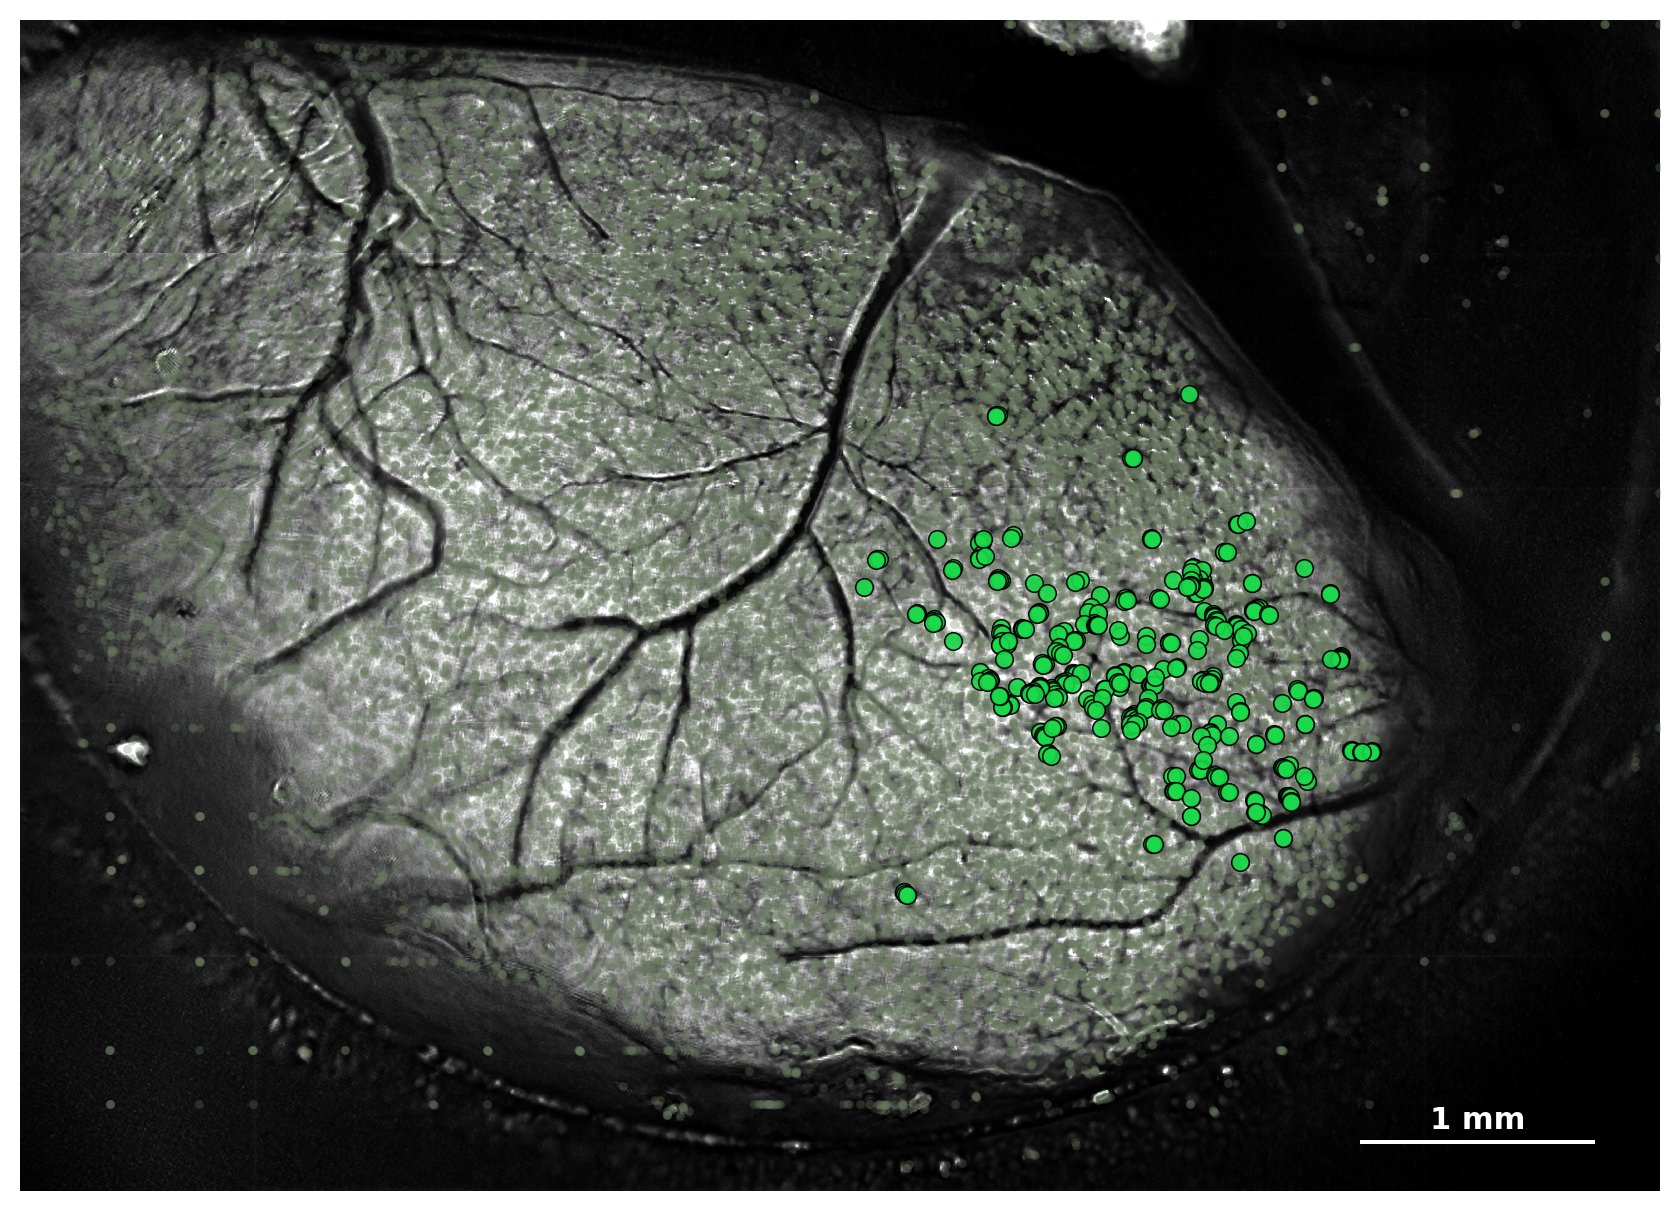

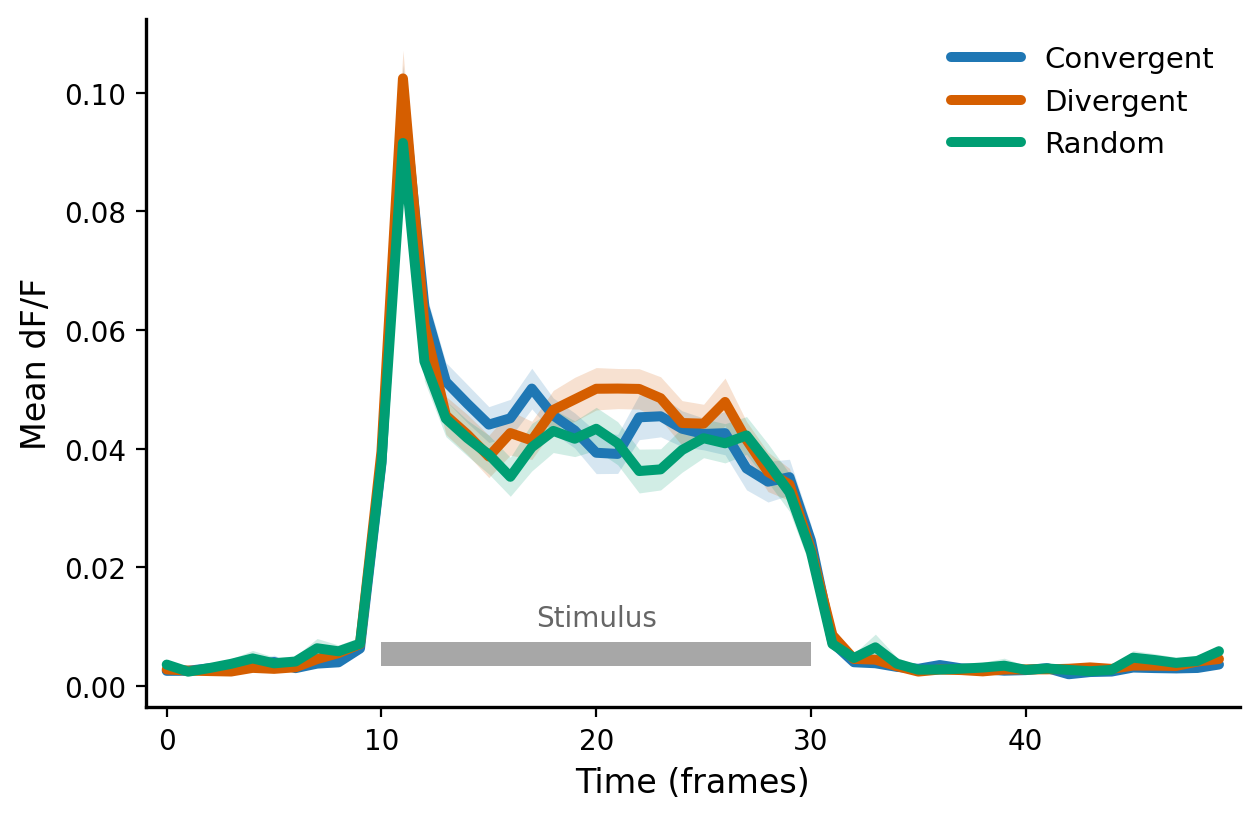

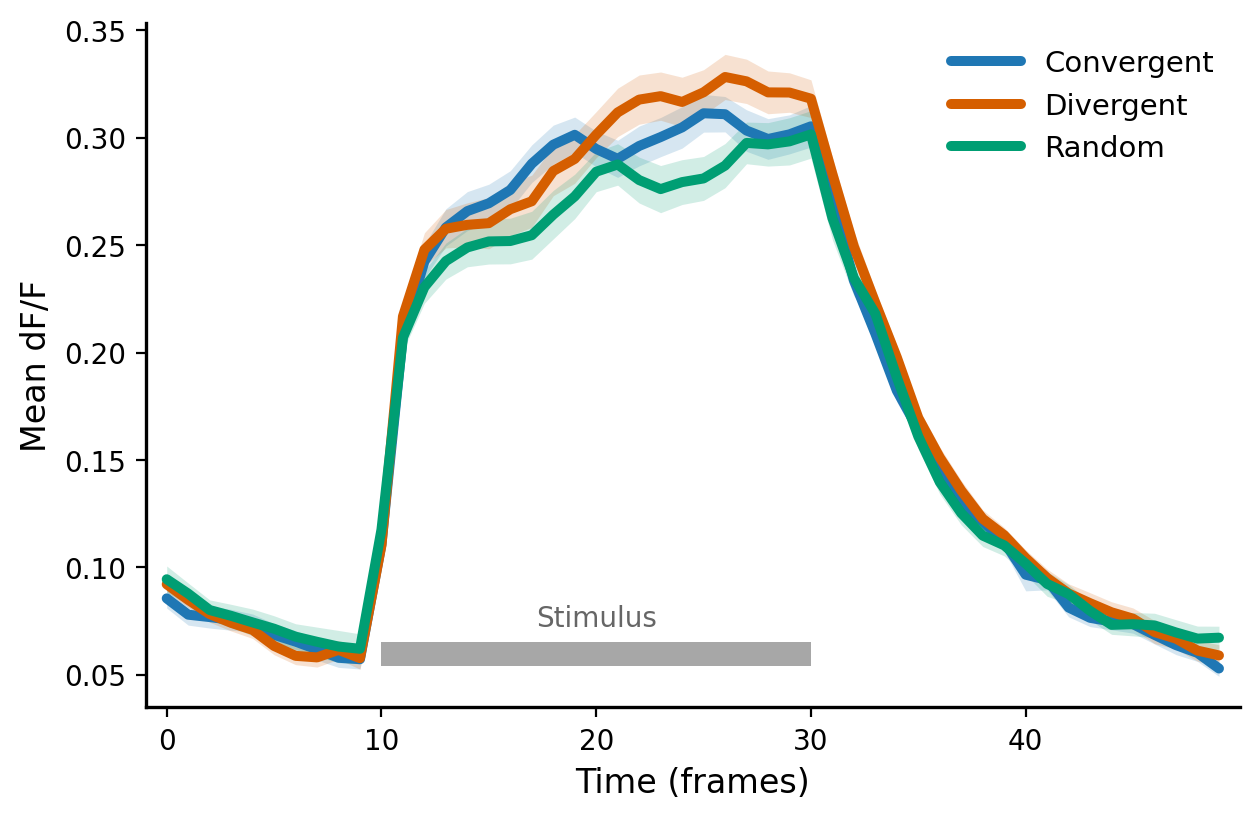

In [48]:
try:
    rr_distribution_plot_pretty(neuron_pos, neuron_pos_spi, data_path, gamma=1.1)
except Exception as e:
    print(f"Error occurred while plotting RR distribution for spike data: {e}")

# rr_distribution_plot_pretty(neuron_pos_flo, neuron_pos_flo, data_path, gamma=1.1)

#plot_rr_population_average(segments_spi, labels_spi)
#plot_rr_population_average(segments_flo, labels_flo)
plot_rr_population_average_pretty(segments_spi, labels_spi)
plot_rr_population_average_pretty(segments_flo, labels_flo)

In [49]:
accuracies, time_points, accuracy_std, n_folds = classify_by_timepoints(segments_flo, labels_flo)
labels_shuffled = np.random.permutation(labels_flo)
accuracies_shu, time_points_shu, accuracy_std_shu, n_folds_shu = classify_by_timepoints(segments_flo, labels_shuffled)

fisher_mv, time_points_fi_mv = FI_by_timepoints_v2(segments_flo, 
                                                   labels_flo, 
                                                   mode="multivariate", 
                                                   reduction=None)
fisher_uv, time_points_fi_uv = FI_by_timepoints_v2(segments_flo, labels_flo, mode="univariate", reduction="mean")
neuron_counts, fi_values = FI_by_neuron_count(segments_flo, labels_flo)

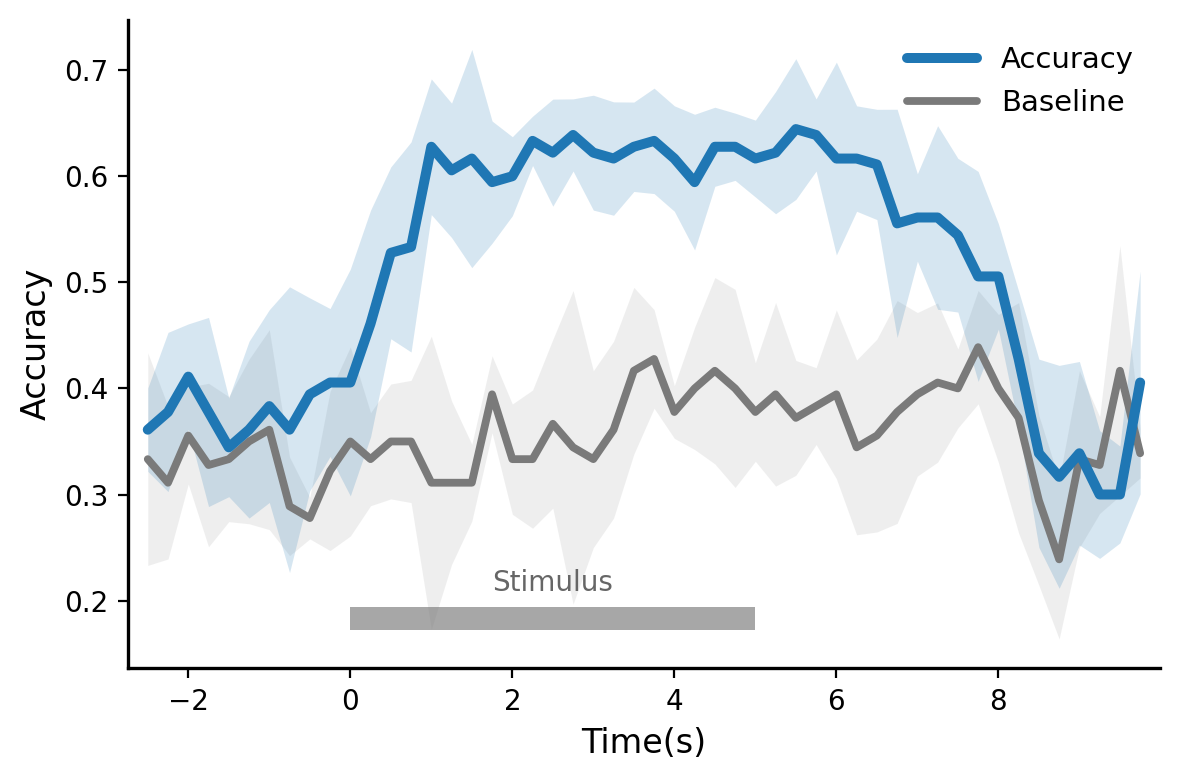

In [50]:
plot_accuracy(time_points=time_points, accuracies=accuracies, baseline=accuracies_shu, accuracy_std=accuracy_std, baseline_std=accuracy_std_shu)

In [51]:
nx_result = compute_network_metrics_by_class(segments_spi, labels_spi, neuron_pos_spi, do_bootstrap=False)

In [52]:
def plot_correlation_violin_optim(nx_result):
    """
    Plot violin plots of correlation coefficient distributions for each stimulus class.
    nx_result: dict
        Output from compute_network_metrics_by_class containing 'corr_matrix' for each class.
    """
    import matplotlib.pyplot as plt
    import numpy as np

    # 类名定义
    CLASS_NAMES = {1: "Convergent", 2: "Divergent", 3: "Random"}
    CLASS_COLORS = {
        1: "#3C5488",  # Convergent: 深蓝 (沉稳，表示汇聚)
        2: "#E64B35",  # Divergent:  朱红 (醒目，表示发散)
        3: "#00A087",  # Random:     蓝绿 (中性，表示随机)
    }
    # 提取每个类别的相关系数（排除对角线）
    corr_data = []
    class_labels = []
    class_order = [1, 2, 3]

    for cls in class_order:
        if cls in nx_result:
            corr_matrix = nx_result[cls]['corr_matrix']
            # 获取上三角的相关系数（排除对角线）
            mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
            corr_values = corr_matrix[mask]
            corr_data.append(corr_values)
            class_labels.append(CLASS_NAMES[cls])

    # 绘制小提琴图
    fig, ax = plt.subplots(figsize=(4, 3), dpi=200)

    # 创建小提琴图
    parts = ax.violinplot(
        corr_data,
        positions=range(len(class_order)),
        widths=0.7,
        showmeans=True,
        showmedians=True,
    )

    # 为每个小提琴设置颜色
    for i, pc in enumerate(parts['bodies']):
        cls = class_order[i]
        pc.set_facecolor(CLASS_COLORS[cls])
        pc.set_alpha(0.7)
        pc.set_edgecolor(CLASS_COLORS[cls])
        pc.set_linewidth(1.2)

    # 设置其他线条的样式
    for partname in ('cbars', 'cmins', 'cmaxes', 'cmedians', 'cmeans'):
        if partname in parts:
            vp = parts[partname]
            vp.set_edgecolor('#333333')
            vp.set_linewidth(1.2)

    # 坐标轴美化
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_linewidth(1.2)
    ax.spines["bottom"].set_linewidth(1.2)

    # 设置 x 轴标签
    ax.set_xticks(range(len(class_order)))
    ax.set_xticklabels(class_labels, fontsize=11)

    # 标签和标题
    ax.set_ylabel('Correlation Coefficient', fontsize=12)
    # ax.set_xlabel('Stimulus Type', fontsize=12)
    # ax.set_title('Distribution of Pairwise Correlations', fontsize=13.5, weight='bold', pad=10)

    # 添加水平参考线
    ax.axhline(y=0, color='#888888', linestyle='--', linewidth=0.8, alpha=0.5, zorder=0)

    fig.tight_layout()
    plt.show()

def plot_network_metrics_bars_optim(
    nx_result,
    metrics=None,
    figsize=(8, 4),
    bar_width=0.6,
    show_values=True,
    value_fontsize=9
):
    """
    绘制网络指标的柱状图
    
    Parameters
    ----------
    nx_result : dict
        compute_network_metrics_by_class 的返回结果
    metrics : list of str, optional
        要绘制的指标列表。如果为 None，则绘制所有可用指标。
        可选指标：
        - 'density': 网络密度
        - 'mean_degree': 平均度
        - 'largest_component': 最大连通分量大小
        - 'avg_clustering': 平均聚类系数
        - 'global_efficiency': 全局效率
        - 'local_efficiency': 局部效率
        - 'transitivity': 传递性
        - 'efficiency': 效率（额外计算）
        - 'modularity': 模块度
        - 'betweenness_mean': 介数中心性均值
    figsize : tuple
        图形大小
    bar_width : float
        柱子宽度
    show_values : bool
        是否在柱子上显示数值
    value_fontsize : int
        数值字体大小
    """
    
    # 类名定义
    CLASS_NAMES = {1: "Convergent", 2: "Divergent", 3: "Random"}
    CLASS_COLORS = {
        1: "#3C5488",  # Convergent: 深蓝 (沉稳，表示汇聚)
        2: "#E64B35",  # Divergent:  朱红 (醒目，表示发散)
        3: "#00A087",  # Random:     蓝绿 (中性，表示随机)
    }
    
    # 默认绘制所有指标
    if metrics is None:
        metrics = [
            'density', 'mean_degree', 'largest_component',
            'avg_clustering', 'global_efficiency', 'local_efficiency',
            'transitivity', 'efficiency', 'modularity', 'betweenness_mean'
        ]
    
    # 指标的显示名称
    metric_labels = {
        'density': 'Network Density',
        'mean_degree': 'Mean Degree',
        'largest_component': 'Largest Component',
        'avg_clustering': 'Avg Clustering',
        'global_efficiency': 'Global Efficiency',
        'local_efficiency': 'Local Efficiency',
        'transitivity': 'Transitivity',
        'efficiency': 'Efficiency',
        'modularity': 'Modularity',
        'betweenness_mean': 'Betweenness (mean)',
    }
    
    class_order = [1, 2, 3]
    n_metrics = len(metrics)
    n_cols = 3
    n_rows = (n_metrics + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize, dpi=200)
    axes = axes.flatten() if n_metrics > 1 else [axes]
    
    for idx, metric in enumerate(metrics):
        ax = axes[idx]
        
        # 提取数据
        values = []
        colors = []
        labels = []
        
        for cls in class_order:
            if cls not in nx_result:
                continue
                
            # 从不同的字段中获取指标值
            if metric in ['density', 'mean_degree', 'largest_component', 
                         'avg_clustering', 'global_efficiency', 'local_efficiency', 
                         'transitivity']:
                value = nx_result[cls]['summary'][metric]
            elif metric == 'efficiency':
                value = nx_result[cls]['efficiency']
            elif metric == 'modularity':
                value = nx_result[cls]['modularity']
            elif metric == 'betweenness_mean':
                value = nx_result[cls]['betweenness_stats']['mean']
            else:
                continue
            
            values.append(value)
            colors.append(CLASS_COLORS[cls])
            labels.append(CLASS_NAMES[cls])
        
        # 绘制柱状图
        x_pos = np.arange(len(values))
        bars = ax.bar(x_pos, values, width=bar_width, color=colors, 
                     alpha=0.8, edgecolor='#333333', linewidth=1.2)
        
        # 在柱子上显示数值
        if show_values:
            for i, (bar, val) in enumerate(zip(bars, values)):
                height = bar.get_height()
                ax.text(bar.get_x() + bar.get_width() / 2., height,
                       f'{val:.3f}',
                       ha='center', va='bottom',
                       fontsize=value_fontsize, color='#333333')
        
        # 坐标轴美化
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.spines["left"].set_linewidth(1.2)
        ax.spines["bottom"].set_linewidth(1.2)
        
        # 设置 x 轴标签
        ax.set_xticks(x_pos)
        ax.set_xticklabels(labels, fontsize=10)
        
        # 标题
        ax.set_title(metric_labels.get(metric, metric), 
                    fontsize=11, weight='bold', pad=8)
        ax.set_ylabel('Value', fontsize=10)
        
        # y 轴从 0 开始
        ax.set_ylim(bottom=0)
    
    # 隐藏多余的子图
    for idx in range(n_metrics, len(axes)):
        axes[idx].set_visible(False)
    
    fig.tight_layout()
    plt.show()




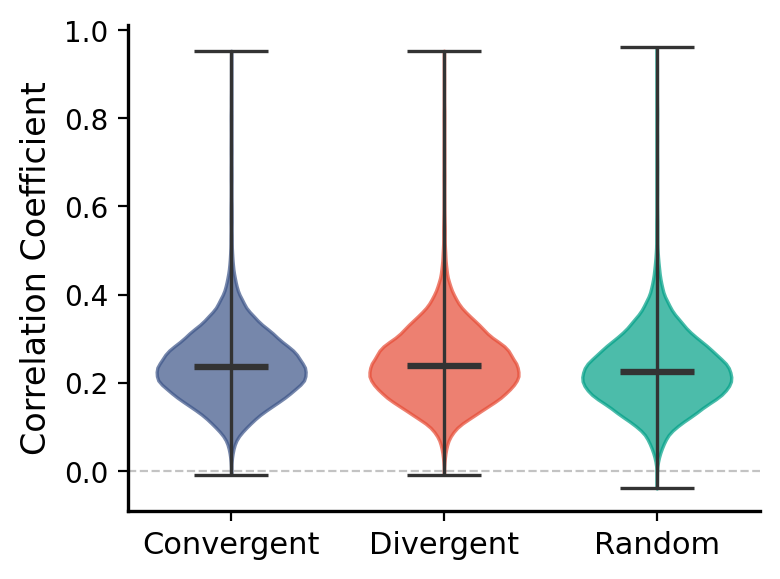

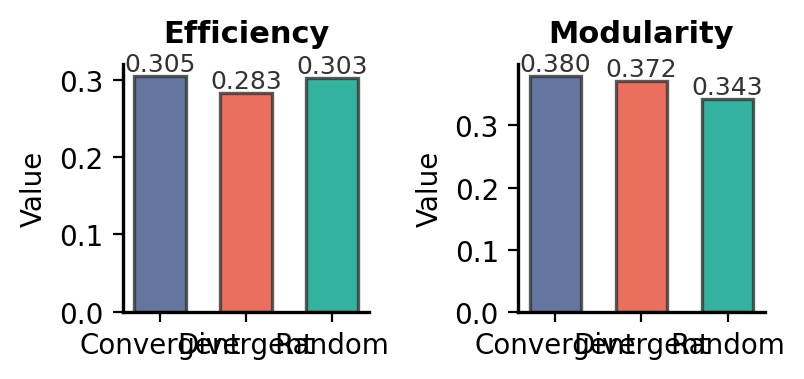

In [53]:
plot_correlation_violin_optim(nx_result)
plot_network_metrics_bars_optim(nx_result, metrics=['efficiency', 'modularity'], figsize=(6,2))


In [54]:
import numpy as np
from sklearn.preprocessing import KBinsDiscretizer

def entropy_from_counts(counts):
    p = counts / counts.sum()
    p = p[p > 0]
    return -np.sum(p * np.log2(p))

def joint_entropy_discrete(mat_2d_int):
    """
    mat_2d_int: shape (N, d), discrete ints
    """
    _, counts = np.unique(mat_2d_int, axis=0, return_counts=True)
    return entropy_from_counts(counts)

def o_information_discrete(X_int):
    """
    X_int: shape (N, n), discrete ints
    """
    N, n = X_int.shape
    H_joint = joint_entropy_discrete(X_int)

    # sum H(X_i)
    H_single_sum = 0.0
    for i in range(n):
        H_single_sum += joint_entropy_discrete(X_int[:, i:i+1])

    # sum H(X_{-i})
    H_minus_sum = 0.0
    all_idx = np.arange(n)
    for i in range(n):
        idx = all_idx[all_idx != i]
        H_minus_sum += joint_entropy_discrete(X_int[:, idx])

    Omega = (n - 2) * H_joint + H_single_sum - H_minus_sum
    return Omega

def omega_timecourse_discretize(data, n_bins=4, strategy="quantile"):
    """
    data: (N, n, t) continuous
    returns: Omega_t (t,)
    """
    N, n, t = data.shape
    Omega_t = np.zeros(t)

    disc = KBinsDiscretizer(
        n_bins=n_bins,
        encode="ordinal",
        strategy="quantile",
        quantile_method="averaged_inverted_cdf"
    )

    for k in range(t):
        X = data[:, :, k]  # (N, n)

        # 可选：按列z-score（常见做法，减少量纲差异）
        Xz = (X - X.mean(axis=0, keepdims=True)) / (X.std(axis=0, keepdims=True) + 1e-12)

        # 每个时间点都用该时间点的样本分布来fit分箱
        X_int = disc.fit_transform(Xz).astype(np.int64)

        Omega_t[k] = o_information_discrete(X_int)

    return Omega_t


def omega_timecourse_subsample(data, k=80, n_repeat=10, n_bins=3):
    N, n, t = data.shape
    Omega_mean = np.zeros(t)
    Omega_sem = np.zeros(t)

    for tt in range(t):
        Omegas = []
        for _ in range(n_repeat):
            idx = np.random.choice(n, k, replace=False)
            X = data[:, idx, tt]   # (N, k)
            disc = KBinsDiscretizer(
                n_bins=n_bins,
                encode="ordinal",
                strategy="quantile",
                quantile_method="averaged_inverted_cdf"
            )
            X_int = disc.fit_transform(X).astype(np.int64)

            Omegas.append(o_information_discrete(X_int))
        Omega_mean[tt] = np.mean(Omegas)
        Omega_sem[tt] = np.std(Omegas) / np.sqrt(n_repeat)

    return Omega_mean, Omega_sem

In [55]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Trial 聚合：计算每个 Trial 的平均活动
# 假设 X_trials 的形状是 (Trial总数, 帧数, 神经元数)
X_trial_averaged = np.mean(segments_spi[:, :, 10:13], axis=2) # 得到 (n_trials, n_neurons)

unique_labels = np.unique(labels_spi)
min_count = min(np.sum(labels_spi == l) for l in unique_labels)

# 2. 平衡数据集
X_balanced_list = []
labels_balanced = []

for label in unique_labels:
    mask = (labels_spi == label)
    X_label = X_trial_averaged[mask]
    
    # 建议：随机采样而非固定取前几个
    indices = np.random.choice(len(X_label), min_count, replace=False)
    X_sampled = X_label[indices]
    
    X_balanced_list.append(X_sampled)
    labels_balanced.extend([label] * min_count)

# 2. 关键修正：将列表转化为单一矩阵 [cite: 1]
X_trial_averaged_balanced = np.vstack(X_balanced_list)
labels_balanced = np.array(labels_balanced)


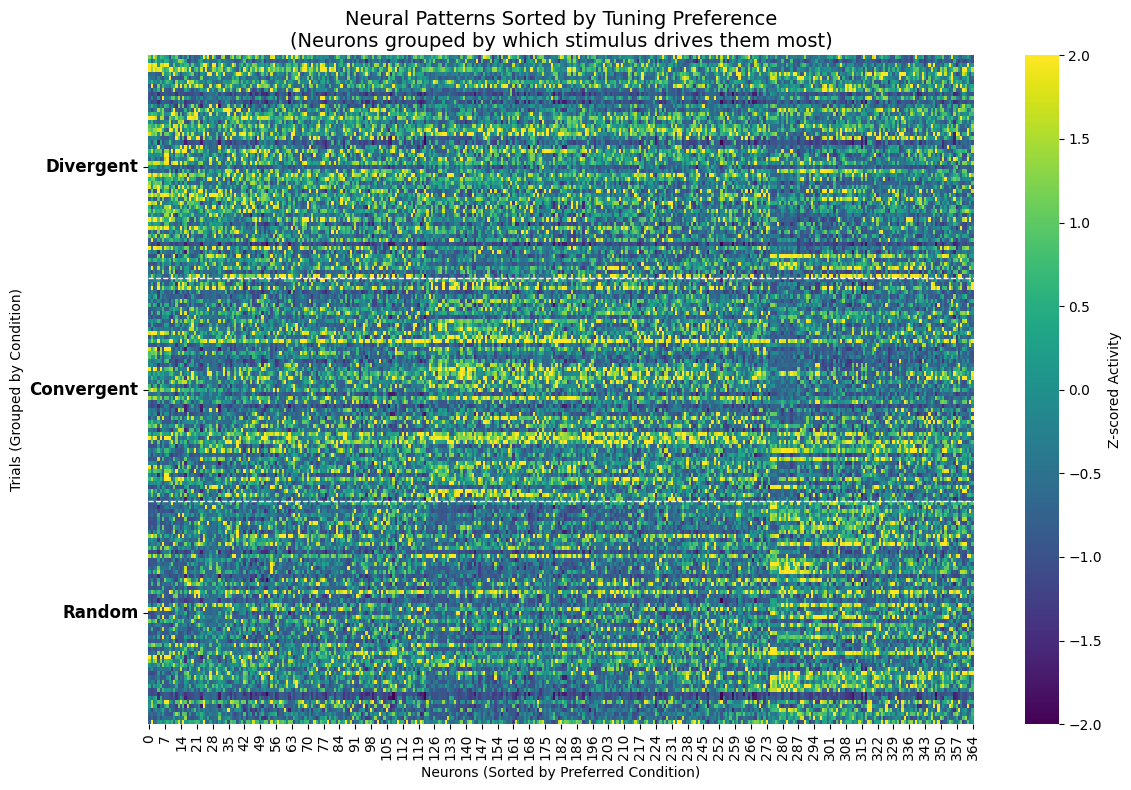

Generating Clustermap (Hierarchical Clustering)...


/beegfs_hdd/data/nfs_share/users/guiyun/nishome/brainnetwork/.venv/lib/python3.13/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


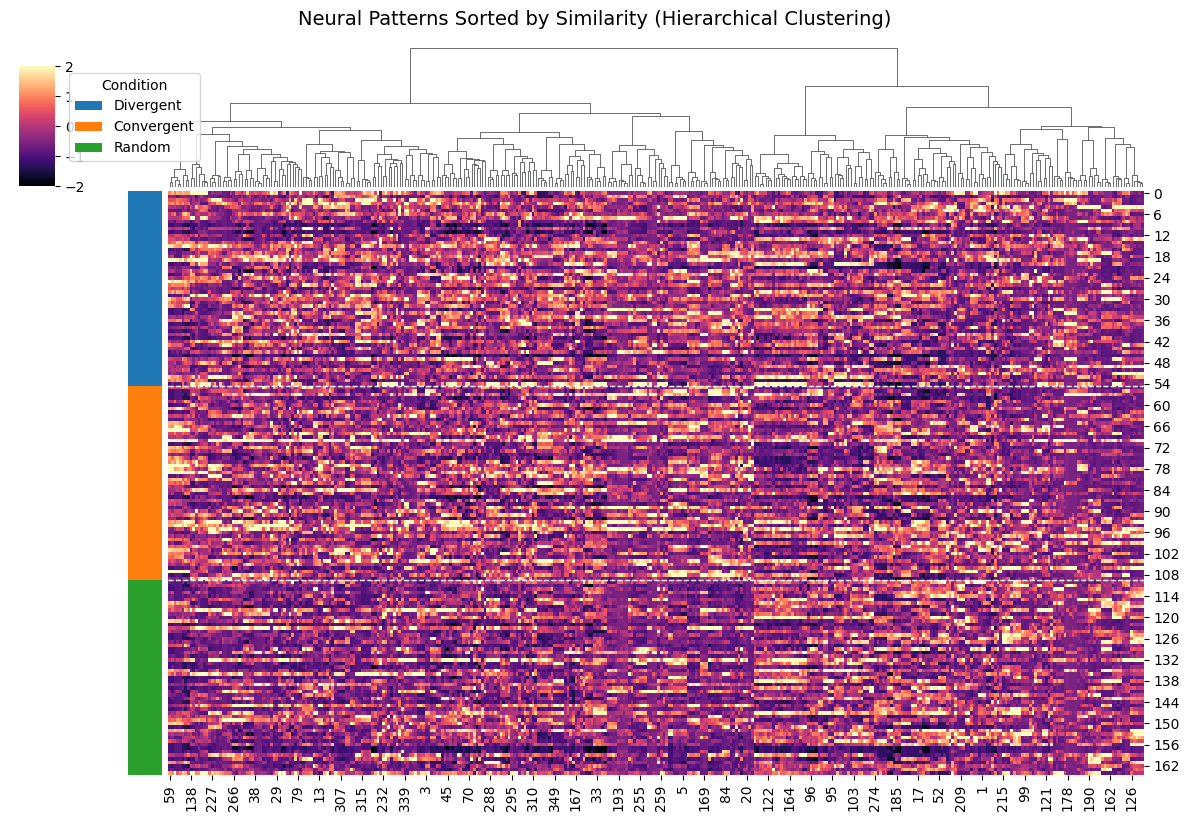

In [56]:
from scipy.stats import zscore

# 定义语义映射
label_names = {1: 'Divergent', 2: 'Convergent', 3: 'Random', 0: 'Resting'}
def plot_sorted_neural_patterns(X, labels, label_map):
    """
    可视化神经元活动热图，通过两种策略对神经元（X轴）进行排序，
    以揭示不同刺激条件（Y轴）下的Pattern差异。
    """
    
    # 1. 数据预处理
    # ------------------------------------------------
    # Z-score 归一化：消除神经元绝对发放率的差异，只看相对变化
    # axis=0 对每一列（神经元）做归一化
    X_norm = zscore(X, axis=0)
    
    # 替换 NaN (如果有些神经元完全不发放，std为0，zscore会产生nan)
    X_norm = np.nan_to_num(X_norm)
    
    unique_labels = np.unique(labels)
    sorted_labels = sorted(unique_labels) # 确保顺序: Divergent, Convergent, Random...
    
    # 获取标签的分界线位置，用于画横线
    label_counts = [np.sum(labels == l) for l in sorted_labels]
    boundaries = np.cumsum(label_counts)[:-1]
    
    # 重新排列 X 的行（Trial），确保它是按 Label 顺序排列的
    # (虽然通常已经是排好的，但为了保险起见)
    trial_sort_idx = np.argsort(labels)
    X_sorted_trials = X_norm[trial_sort_idx]
    labels_sorted = labels[trial_sort_idx]
    
    # ------------------------------------------------
    # 策略一：偏好性排序 (Preference Sorting)
    # ------------------------------------------------
    # 计算每个神经元在各条件下的平均活动
    n_neurons = X.shape[1]
    neuron_means = np.zeros((len(unique_labels), n_neurons))
    
    for i, l in enumerate(sorted_labels):
        # 找到该条件下的所有行
        mask = (labels == l)
        # 计算该条件下每个神经元的均值
        neuron_means[i, :] = np.mean(X_norm[mask], axis=0)
        
    # 找出每个神经元在哪个条件下最强 (Argmax)
    peak_condition_idx = np.argmax(neuron_means, axis=0)
    
    # 在同一个条件下，再按强度排个序，为了视觉更好看
    peak_magnitude = np.max(neuron_means, axis=0)
    
    # 综合排序键值: 先按条件ID排，再按强度排
    # 技巧: use lexsort. Primary key is last argument.
    sort_key = np.lexsort((-peak_magnitude, peak_condition_idx))
    
    X_pref_sorted = X_sorted_trials[:, sort_key]
    
    # ------------------------------------------------
    # 绘图 1: 偏好性排序热图
    # ------------------------------------------------
    fig, ax = plt.subplots(figsize=(12, 8))
    sns.heatmap(X_pref_sorted, ax=ax, cmap='viridis', vmin=-2, vmax=2, cbar_kws={'label': 'Z-scored Activity'})
    
    # 画水平线分隔不同条件
    for b in boundaries:
        ax.hlines(b, *ax.get_xlim(), colors='white', linestyles='--', linewidth=1)
        
    # 标注 Y 轴
    # 计算每个 Block 的中心位置
    y_centers = []
    current = 0
    for count in label_counts:
        y_centers.append(current + count/2)
        current += count
        
    ax.set_yticks(y_centers)
    ax.set_yticklabels([label_map[l] for l in sorted_labels], rotation=0, fontsize=12, fontweight='bold')
    
    ax.set_title("Neural Patterns Sorted by Tuning Preference\n(Neurons grouped by which stimulus drives them most)", fontsize=14)
    ax.set_xlabel("Neurons (Sorted by Preferred Condition)")
    ax.set_ylabel("Trials (Grouped by Condition)")
    
    plt.tight_layout()
    plt.show()

    # ------------------------------------------------
    # 策略二：层次聚类 (Hierarchical Clustering)
    # ------------------------------------------------
    # 这会展示神经元的自然功能团
    print("Generating Clustermap (Hierarchical Clustering)...")
    
    # 创建行颜色条
    label_colors = {l: sns.color_palette("tab10")[i] for i, l in enumerate(unique_labels)}
    row_colors = [label_colors[l] for l in labels_sorted]
    
    g = sns.clustermap(X_sorted_trials, 
                       method='ward', # 聚类算法
                       metric='euclidean',
                       col_cluster=True, # 对神经元聚类
                       row_cluster=False, # 不对 Trial 聚类 (保持条件顺序)
                       row_colors=row_colors,
                       cmap='magma', vmin=-2, vmax=2,
                       figsize=(12, 8),
                       dendrogram_ratio=(0.1, 0.2),
                       cbar_pos=(0.02, 0.8, 0.03, 0.15))
    
    # 添加水平线
    for b in boundaries:
        g.ax_heatmap.hlines(b, *g.ax_heatmap.get_xlim(), colors='white', linestyles='--', linewidth=1)
        
    g.fig.suptitle("Neural Patterns Sorted by Similarity (Hierarchical Clustering)", y=1.02, fontsize=14)
    
    # 手动添加 Legend
    from matplotlib.patches import Patch
    handles = [Patch(facecolor=label_colors[l], label=label_map[l]) for l in sorted_labels]
    plt.legend(handles=handles, title='Condition', bbox_to_anchor=(1.2, 1), loc='upper left')
    
    plt.show()

# 运行代码
# 确保 X_trial_averaged_balanced 是 (n_trials, n_neurons)
plot_sorted_neural_patterns(X_trial_averaged_balanced, labels_balanced, label_names)

In [60]:
# Experiment configuration
t_stimulus = 10
l_stimulus = 20
reliability_threshold = 0.75
snr_threshold = 0.8

def rr_selection_class(trials, labels, t_stimulus=t_stimulus, l_stimulus=l_stimulus, 
                 alpha_fdr=0.05, alpha_level=0.05, 
                 reliability_threshold=reliability_threshold, snr_threshold=snr_threshold, 
                 effect_size_threshold=0.5, response_ratio_threshold=0.8, 
                 max_n=2000):
    """
    快速RR神经元筛选 (按类分别计算后取并集)
    
    逻辑变更:
    1. 遍历 Label 1, 2, 3。
    2. 在每个 Label 内部计算响应性(Effect Size)和可靠性(SNR)。
    3. 筛选出该 Label 下的 RR 神经元。
    4. 将所有 Label 筛选出的神经元取并集 (Union)。
    """
    print("使用快速RR筛选算法 (按类分别筛选取并集)...")

    n_trials_total, n_neurons, n_timepoints = trials.shape
    
    # 定义时间窗口
    baseline_pre = np.arange(0, t_stimulus)
    baseline_post = np.arange(t_stimulus + l_stimulus, n_timepoints)
    stimulus_window = np.arange(t_stimulus, t_stimulus + l_stimulus)
    
    # 用于存储最终选中的神经元索引（使用集合自动去重，实现并集逻辑）
    rr_neurons = {}
    
    # 指定需要分析的类别
    target_classes = [1, 2, 3]
    
    for target_class in target_classes:
        # 1. 提取当前类别的试次
        class_mask = (labels == target_class)
        class_trials = trials[class_mask]
        
        n_class_trials = class_trials.shape[0]
        
        if n_class_trials == 0:
            print(f"警告: 类别 {target_class} 没有对应的试次，跳过。")
            continue
            
        # print(f"正在处理类别 {target_class}: {n_class_trials} 个试次")
        
        # 2. 响应性检测 - 向量化计算 (针对当前类别)
        
        # 计算基线 (Pre + Post)
        # mean (trials, neurons)
        cls_baseline_pre_mean = np.mean(class_trials[:, :, baseline_pre], axis=2)
        cls_baseline_post_mean = np.mean(class_trials[:, :, baseline_post], axis=2)
        cls_baseline_mean = (cls_baseline_pre_mean + cls_baseline_post_mean) / 2
        
        # std (trials, neurons)
        cls_baseline_pre_std = np.std(class_trials[:, :, baseline_pre], axis=2)
        cls_baseline_post_std = np.std(class_trials[:, :, baseline_post], axis=2)
        cls_baseline_std = (cls_baseline_pre_std + cls_baseline_post_std) / 2
        
        # 计算刺激期
        cls_stimulus_mean = np.mean(class_trials[:, :, stimulus_window], axis=2)
        cls_stimulus_std = np.std(class_trials[:, :, stimulus_window], axis=2)
        
        # 计算 Cohen's d 效应大小
        # pooled_std
        cls_pooled_std = np.sqrt((cls_baseline_std**2 + cls_stimulus_std**2) / 2)
        cls_effect_size = np.abs(cls_stimulus_mean - cls_baseline_mean) / (cls_pooled_std + 1e-8)
        
        # 筛选1：响应性 (Enhanced)
        # 标准：平均效应大小 > 阈值 且 刺激均值 > 基线均值 (兴奋性)
        cls_response_ratio = np.mean(cls_effect_size > effect_size_threshold, axis=0)
        
        # 注意：这里保持你的逻辑，既要 response_ratio 达标，又要总体均值是增强的(兴奋性)
        is_enhanced_mean = np.mean(cls_stimulus_mean > cls_baseline_mean, axis=0) > response_ratio_threshold
        is_responsive = (cls_response_ratio > response_ratio_threshold) & is_enhanced_mean
        
        class_enhanced_indices = np.where(is_responsive)[0]

        # 3. 可靠性检测 (Reliability)
        
        # 信噪比 SNR
        cls_signal_strength = np.abs(cls_stimulus_mean - cls_baseline_mean)
        cls_noise_level = cls_baseline_std + 1e-8
        cls_snr = cls_signal_strength / cls_noise_level
        
        # 筛选2：可靠性
        cls_reliability_ratio = np.mean(cls_snr > snr_threshold, axis=0)
        class_reliable_indices = np.where(cls_reliability_ratio >= reliability_threshold)[0]
        
        # 4. 取当前类别的交集 (既响应又可靠)
        # intersect1d 用于取两个数组的交集
        class_rr_indices = np.intersect1d(class_enhanced_indices, class_reliable_indices)
        
        # 5. 加入到总集合中 (Union 操作)
        rr_neurons[target_class] = set(class_rr_indices)
        
        print(f"  - 类别 {target_class} 贡献了 {len(class_rr_indices)} 个 RR 神经元")
    
    return rr_neurons

rr_neurons_spi = rr_selection_class(segments_spi, labels_spi)
rr_neurons_flo = rr_selection_class(segments_flo, labels_flo)

使用快速RR筛选算法 (按类分别筛选取并集)...
  - 类别 1 贡献了 262 个 RR 神经元
  - 类别 2 贡献了 253 个 RR 神经元
  - 类别 3 贡献了 188 个 RR 神经元
使用快速RR筛选算法 (按类分别筛选取并集)...
  - 类别 1 贡献了 577 个 RR 神经元
  - 类别 2 贡献了 520 个 RR 神经元
  - 类别 3 贡献了 414 个 RR 神经元
